In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load only required columns
df = pd.read_csv(
    "sales.csv",
    usecols=["date", "quantity"]
)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (3150463, 2)

First 5 Rows:


,date,quantity
0,2023-08-04,1.000
1,2023-08-04,3.000
2,2023-08-04,0.822
3,2023-08-04,1.000
4,2023-08-04,7.000



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150463 entries, 0 to 3150462
Data columns (total 2 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   quantity  float64
dtypes: float64(1), object(1)
memory usage: 48.1+ MB

Missing Values:
date        0
quantity    1
dtype: int64


In [2]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Remove missing values
df = df.dropna(subset=["date", "quantity"])

# Calculate total sales quantity per day
daily_sales = df.groupby("date")["quantity"].sum().reset_index()

print("Daily Sales Data:")
display(daily_sales.head())

print("\nDaily Sales Shape:", daily_sales.shape)

Daily Sales Data:


,date,quantity
0,2022-08-28,26137.958
1,2022-08-29,26978.320
2,2022-08-30,25700.895
3,2022-08-31,28353.127
4,2022-09-01,35681.896



Daily Sales Shape: (650, 2)


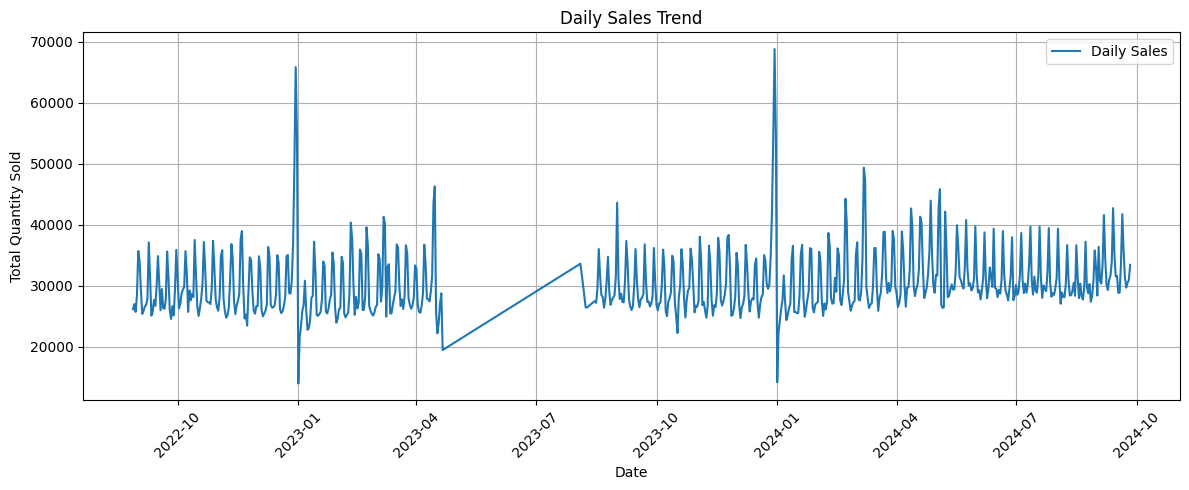

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Daily Sales"
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [4]:
# Calculate 7-day moving average
daily_sales["Moving_Average_7"] = (
    daily_sales["quantity"]
    .rolling(window=7)
    .mean()
)

print("Sales with 7-Day Moving Average:")
display(daily_sales.head(10))

Sales with 7-Day Moving Average:


,date,quantity,Moving_Average_7
0,2022-08-28,26137.958,NaN
1,2022-08-29,26978.320,NaN
2,2022-08-30,25700.895,NaN
3,2022-08-31,28353.127,NaN
4,2022-09-01,35681.896,NaN
5,2022-09-02,34087.996,NaN
6,2022-09-03,29365.221,29472.201857
7,2022-09-04,25353.238,29360.099000
8,2022-09-05,25836.706,29197.011286
9,2022-09-06,26565.214,29320.485429


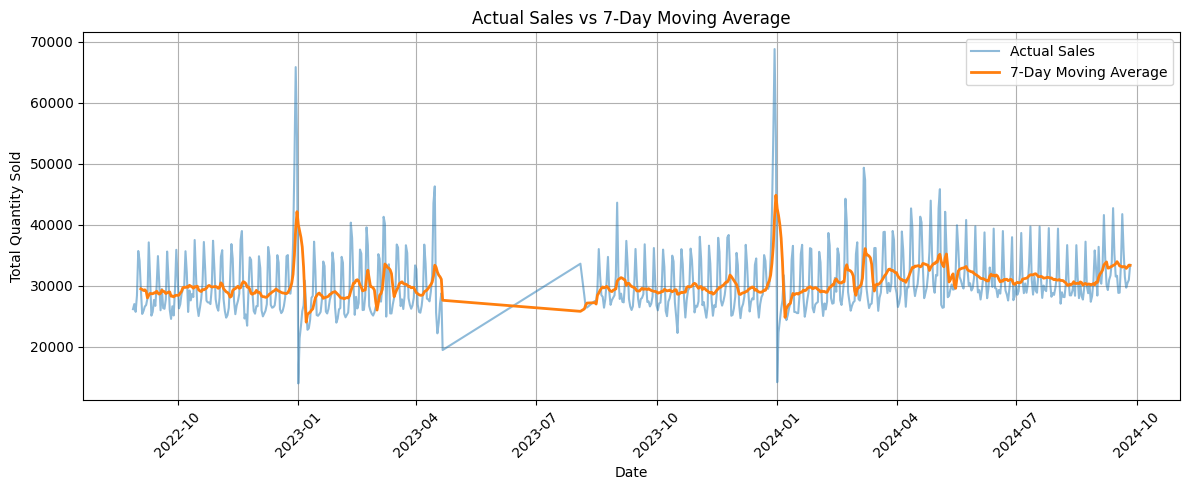

In [5]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Actual Sales",
    alpha=0.5
)

plt.plot(
    daily_sales["date"],
    daily_sales["Moving_Average_7"],
    label="7-Day Moving Average",
    linewidth=2
)

plt.title("Actual Sales vs 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Predict the next 7 days using the latest 7-day average

last_7_days_average = daily_sales["quantity"].tail(7).mean()

last_date = daily_sales["date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7
)

predicted_sales = pd.DataFrame({
    "date": future_dates,
    "Predicted_Sales": [last_7_days_average] * 7
})

print("Next 7 Days Sales Prediction:")
display(predicted_sales)

print(f"\nAverage predicted sales per day: {last_7_days_average:.2f}")

Next 7 Days Sales Prediction:


,date,Predicted_Sales
0,2024-09-27,33333.007714
1,2024-09-28,33333.007714
2,2024-09-29,33333.007714
3,2024-09-30,33333.007714
4,2024-10-01,33333.007714
5,2024-10-02,33333.007714
6,2024-10-03,33333.007714



Average predicted sales per day: 33333.01


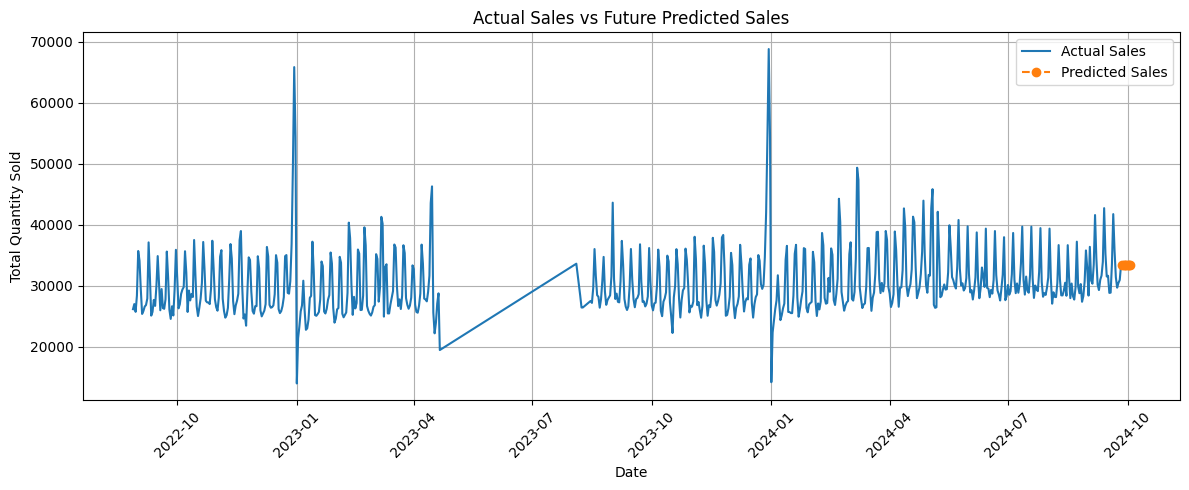

In [7]:
# Plot actual sales and future predicted sales

plt.figure(figsize=(12, 5))

# Actual sales
plt.plot(
    daily_sales["date"],
    daily_sales["quantity"],
    label="Actual Sales"
)

# Future predictions
plt.plot(
    predicted_sales["date"],
    predicted_sales["Predicted_Sales"],
    marker="o",
    linestyle="--",
    label="Predicted Sales"
)

plt.title("Actual Sales vs Future Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
print("Sales/Trend Prediction Summary")
print("--------------------------------")

print(f"Total days analyzed: {len(daily_sales)}")
print(f"Average daily sales: {daily_sales['quantity'].mean():.2f}")
print(f"Maximum daily sales: {daily_sales['quantity'].max():.2f}")
print(f"Minimum daily sales: {daily_sales['quantity'].min():.2f}")
print(f"7-day average sales: {last_7_days_average:.2f}")

print()
print("Key Observations:")
print("1. Daily sales show noticeable fluctuations over time.")
print("2. The 7-day moving average smooths short-term fluctuations.")
print("3. Some dates show significant sales spikes.")
print("4. The latest 7-day average was used to predict the next 7 days.")
print("5. The prediction provides a simple baseline for future sales.")

Sales/Trend Prediction Summary
--------------------------------
Total days analyzed: 650
Average daily sales: 30393.09
Maximum daily sales: 68809.42
Minimum daily sales: 13952.71
7-day average sales: 33333.01

Key Observations:
1. Daily sales show noticeable fluctuations over time.
2. The 7-day moving average smooths short-term fluctuations.
3. Some dates show significant sales spikes.
4. The latest 7-day average was used to predict the next 7 days.
5. The prediction provides a simple baseline for future sales.
